 # Magnetic Field Models in Geopack



 This notebook provides a comprehensive guide to using the Tsyganenko magnetic field models (T89, T96, T01, T04) in the geopack library,

 while also supporting **internal** field models:



 - **Dipole internal field** (via `dip(x, y, z)`; vectorized inputs are supported; `x,y,z` are GSM)

 - **IGRF internal field** (via geopack IGRF routines)



 ## Table of Contents

 1. [Overview of Models](#overview)

 2. [Model Parameters](#parameters)

 3. [Basic Usage](#basic-usage)

 4. [Vectorized Models](#vectorized)

 5. [Model Comparison (TOTAL field)](#comparison)

 6. [Field Line Visualization](#visualization)

 7. [Performance Analysis](#performance)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib import cm
import geopack
import time
from datetime import datetime

# Dipole / recalc helpers
from geopack import recalc, dip

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline


# ============================================================
# Helpers: Internal / External / Total field
# ============================================================

def internal_field(model: str, x, y, z):
    """
    Internal magnetic field model.

    Parameters
    ----------
    model : str
        "dipole" or "igrf"
    x, y, z : float or ndarray
        Position in Earth radii. For dipole: GSM coordinates (vectorized OK).
        For IGRF: uses geopack IGRF function in this notebook (kept consistent with original usage).

    Returns
    -------
    bx, by, bz : float or ndarray
        Internal field components (nT).
    """
    model = model.lower()
    is_vec = np.ndim(x) > 0

    if model in ("dip", "dipole"):
        # Dipole supports vectorized arrays and is called as dip(x,y,z)
        # NOTE: x,y,z are GSM as requested.
        return dip(x, y, z)

    if model == "igrf":
        # Use geopack IGRF function as in the original notebook.
        # If your workflow requires strict coordinate-system handling (GSM vs GSW),
        # add explicit conversions here.
        if is_vec:
            return geopack.igrf_gsw_vectorized(x, y, z)
        return geopack.igrf_gsw(x, y, z)

    raise ValueError(f"Unknown internal field model: {model}")


def tsyganenko_external(ts_model: str, params, ps, x, y, z):
    """
    Tsyganenko EXTERNAL field only.

    Parameters
    ----------
    ts_model : str
        "t89", "t96", "t01", "t04"
    params :
        t89 -> iopt (int)
        others -> parmod array (len=10)
    ps :
        Dipole tilt (from recalc)
    x, y, z : float or ndarray
        Position in GSM (RE)

    Returns
    -------
    bx, by, bz : float or ndarray
        External field components (nT).
    """
    ts_model = ts_model.lower()
    is_vec = np.ndim(x) > 0

    if ts_model == "t89":
        if is_vec:
            return geopack.t89_vectorized(params, ps, x, y, z)
        return geopack.t89(params, ps, x, y, z)

    if ts_model == "t96":
        if is_vec:
            return geopack.t96_vectorized(params, ps, x, y, z)
        return geopack.t96(params, ps, x, y, z)

    if ts_model == "t01":
        if is_vec:
            return geopack.t01_vectorized(params, ps, x, y, z)
        return geopack.t01(params, ps, x, y, z)

    if ts_model == "t04":
        if is_vec:
            return geopack.t04_vectorized(params, ps, x, y, z)
        return geopack.t04(params, ps, x, y, z)

    raise ValueError(f"Unknown Tsyganenko model: {ts_model}")


def total_field(internal_model: str, ts_model: str, ts_params, ps, x, y, z):
    """
    IMPORTANT:
      The Tsyganenko models return EXTERNAL field only.
      The physical (total) field is:

        B_total = B_internal (dipole or IGRF) + B_external (Tsyganenko)

    Returns
    -------
    bx_tot, by_tot, bz_tot, bx_int, by_int, bz_int, bx_ext, by_ext, bz_ext
    """
    bx_int, by_int, bz_int = internal_field(internal_model, x, y, z)
    bx_ext, by_ext, bz_ext = tsyganenko_external(ts_model, ts_params, ps, x, y, z)

    bx_tot = bx_int + bx_ext
    by_tot = by_int + by_ext
    bz_tot = bz_int + bz_ext

    return bx_tot, by_tot, bz_tot, bx_int, by_int, bz_int, bx_ext, by_ext, bz_ext



Load IGRF coefficients ...


 ## 1. Overview of Models <a name="overview"></a>



 The Tsyganenko models are empirical representations of Earth's magnetospheric magnetic field:



 - **T89**: Simplest model, parameterized by Kp index (7 discrete levels)

 - **T96**: Includes solar wind pressure, IMF By and Bz

 - **T01**: Storm-time model with additional parameters

 - **T04**: Most comprehensive storm-time model



 **Crucial point:** all Tsyganenko models provide the **external** magnetic field only.

 Therefore, the physical (total) field is:



 **B_total = B_internal (dipole or IGRF) + B_external (Tsyganenko)**

In [2]:
# Initialize geopack for a specific time
ut = datetime(2015, 3, 17, 12, 0, 0).timestamp()  # St. Patrick's Day storm
ps = recalc(ut)

print(f"Time: {datetime.fromtimestamp(ut)}")
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")
print(f"\nAvailable models:")
print("- geopack.t89 / t89_vectorized")
print("- geopack.t96 / t96_vectorized")
print("- geopack.t01 / t01_vectorized")
print("- geopack.t04 / t04_vectorized")
print("\nInternal field choices in this notebook:")
print("- 'dipole' via dip(x, y, z)  (GSM; vectorized OK)")
print("- 'igrf'   via geopack.igrf_gsw(_vectorized)")


Time: 2015-03-17 12:00:00
Dipole tilt angle: -9.90 degrees

Available models:
- geopack.t89 / t89_vectorized
- geopack.t96 / t96_vectorized
- geopack.t01 / t01_vectorized
- geopack.t04 / t04_vectorized

Internal field choices in this notebook:
- 'dipole' via dip(x, y, z)  (GSM; vectorized OK)
- 'igrf'   via geopack.igrf_gsw(_vectorized)


 ## 2. Model Parameters <a name="parameters"></a>



 Each model requires different parameters based on geomagnetic conditions:

In [3]:
# T89 Model Parameters
# Single parameter: Kp index (1-7)
kp_values = {
    1: "Kp = 0, 0+",
    2: "Kp = 1-, 1, 1+",
    3: "Kp = 2-, 2, 2+",
    4: "Kp = 3-, 3, 3+",
    5: "Kp = 4-, 4, 4+",
    6: "Kp = 5-, 5, 5+",
    7: "Kp >= 6-"
}

print("T89 Model - Kp Parameter Values:")
for key, desc in kp_values.items():
    print(f"  iopt={key}: {desc}")

# T96 Model Parameters
print("\nT96 Model - Parameter Array:")
print("  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure")
print("  parmod[1] = Dst (nT)      - Disturbance storm time index")
print("  parmod[2] = ByIMF (nT)    - IMF By component")
print("  parmod[3] = BzIMF (nT)    - IMF Bz component")
print("  parmod[4:10]              - Unused (set to 0)")

# T01 Model Parameters
print("\nT01 Model - Parameter Array:")
print("  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure")
print("  parmod[1] = Dst (nT)      - Disturbance storm time index")
print("  parmod[2] = ByIMF (nT)    - IMF By component")
print("  parmod[3] = BzIMF (nT)    - IMF Bz component")
print("  parmod[4] = G1            - N-index for Region 1 current")
print("  parmod[5] = G2            - N-index for Region 2 current")
print("  parmod[6:10]              - Unused")

# T04 Model Parameters
print("\nT04 Model - Parameter Array:")
print("  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure")
print("  parmod[1] = Dst (nT)      - Disturbance storm time index")
print("  parmod[2] = ByIMF (nT)    - IMF By component")
print("  parmod[3] = BzIMF (nT)    - IMF Bz component")
print("  parmod[4] = W1            - W-index coefficient 1")
print("  parmod[5] = W2            - W-index coefficient 2")
print("  parmod[6] = W3            - W-index coefficient 3")
print("  parmod[7] = W4            - W-index coefficient 4")
print("  parmod[8] = W5            - W-index coefficient 5")
print("  parmod[9] = W6            - W-index coefficient 6")


T89 Model - Kp Parameter Values:
  iopt=1: Kp = 0, 0+
  iopt=2: Kp = 1-, 1, 1+
  iopt=3: Kp = 2-, 2, 2+
  iopt=4: Kp = 3-, 3, 3+
  iopt=5: Kp = 4-, 4, 4+
  iopt=6: Kp = 5-, 5, 5+
  iopt=7: Kp >= 6-

T96 Model - Parameter Array:
  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure
  parmod[1] = Dst (nT)      - Disturbance storm time index
  parmod[2] = ByIMF (nT)    - IMF By component
  parmod[3] = BzIMF (nT)    - IMF Bz component
  parmod[4:10]              - Unused (set to 0)

T01 Model - Parameter Array:
  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure
  parmod[1] = Dst (nT)      - Disturbance storm time index
  parmod[2] = ByIMF (nT)    - IMF By component
  parmod[3] = BzIMF (nT)    - IMF Bz component
  parmod[4] = G1            - N-index for Region 1 current
  parmod[5] = G2            - N-index for Region 2 current
  parmod[6:10]              - Unused

T04 Model - Parameter Array:
  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure
  parmod[1] = Dst (nT)      -

 ## 3. Basic Usage <a name="basic-usage"></a>



 ### Example: Calculate magnetic field at a single point



 In this notebook we will always be explicit:

 - Tsyganenko output = **external field only**

 - Physical field = **internal + external**

In [4]:
# Define a point in GSM coordinates
x_gsm = -6.0  # Magnetotail
y_gsm = 3.0
z_gsm = 2.0

# Choose internal field model: "dipole" or "igrf"
internal_model = "dipole"  # change to "igrf" if desired

print(f"Position: ({x_gsm}, {y_gsm}, {z_gsm}) RE in GSM coordinates")
print(f"Internal model: {internal_model}")
print("=" * 60)

# T89 external model - moderate activity (Kp = 3)
iopt = 4  # Kp = 3
bx_tot89, by_tot89, bz_tot89, bx_int89, by_int89, bz_int89, bx_ext89, by_ext89, bz_ext89 = total_field(
    internal_model, "t89", iopt, ps, x_gsm, y_gsm, z_gsm
)
b89_total = np.sqrt(bx_tot89**2 + by_tot89**2 + bz_tot89**2)

print(f"\nT89 Model (Kp = 3) + {internal_model.upper()} (TOTAL):")
print(f"  Internal: Bx = {bx_int89:.2f} nT, By = {by_int89:.2f} nT, Bz = {bz_int89:.2f} nT")
print(f"  External: Bx = {bx_ext89:.2f} nT, By = {by_ext89:.2f} nT, Bz = {bz_ext89:.2f} nT")
print(f"  TOTAL   : Bx = {bx_tot89:.2f} nT, By = {by_tot89:.2f} nT, Bz = {bz_tot89:.2f} nT")
print(f"  |B|_total = {b89_total:.2f} nT")

# T96 external model - storm conditions
parmod96 = np.zeros(10)
parmod96[0] = 3.0   # Pdyn = 3 nPa
parmod96[1] = -50.0 # Dst = -50 nT (moderate storm)
parmod96[2] = 0.0   # ByIMF = 0 nT
parmod96[3] = -5.0  # BzIMF = -5 nT (southward)

bx_tot96, by_tot96, bz_tot96, bx_int96, by_int96, bz_int96, bx_ext96, by_ext96, bz_ext96 = total_field(
    internal_model, "t96", parmod96, ps, x_gsm, y_gsm, z_gsm
)
b96_total = np.sqrt(bx_tot96**2 + by_tot96**2 + bz_tot96**2)

print(f"\nT96 Model (storm conditions) + {internal_model.upper()} (TOTAL):")
print(f"  Internal: Bx = {bx_int96:.2f} nT, By = {by_int96:.2f} nT, Bz = {bz_int96:.2f} nT")
print(f"  External: Bx = {bx_ext96:.2f} nT, By = {by_ext96:.2f} nT, Bz = {bz_ext96:.2f} nT")
print(f"  TOTAL   : Bx = {bx_tot96:.2f} nT, By = {by_tot96:.2f} nT, Bz = {bz_tot96:.2f} nT")
print(f"  |B|_total = {b96_total:.2f} nT")

# Internal-only at this point (for reference)
bx_int, by_int, bz_int = internal_field(internal_model, x_gsm, y_gsm, z_gsm)
b_int_total = np.sqrt(bx_int**2 + by_int**2 + bz_int**2)

print(f"\nInternal-only ({internal_model.upper()}):")
print(f"  |B|_internal = {b_int_total:.2f} nT")

# External contribution magnitude relative to internal magnitude (rough indicator)
print(f"\nExternal field contribution (magnitude ratio):")
print(f"  T89: |B_total|/|B_int| = {b89_total/b_int_total:.2f}")
print(f"  T96: |B_total|/|B_int| = {b96_total/b_int_total:.2f}")


Position: (-6.0, 3.0, 2.0) RE in GSM coordinates
Internal model: dipole

T89 Model (Kp = 3) + DIPOLE (TOTAL):
  Internal: Bx = 81.03 nT, By = -48.00 nT, Bz = 53.77 nT
  External: Bx = 34.73 nT, By = -12.73 nT, Bz = -29.49 nT
  TOTAL   : Bx = 115.77 nT, By = -60.73 nT, Bz = 24.28 nT
  |B|_total = 132.97 nT

T96 Model (storm conditions) + DIPOLE (TOTAL):
  Internal: Bx = 81.03 nT, By = -48.00 nT, Bz = 53.77 nT
  External: Bx = 53.62 nT, By = -22.08 nT, Bz = -39.40 nT
  TOTAL   : Bx = 134.65 nT, By = -70.08 nT, Bz = 14.38 nT
  |B|_total = 152.48 nT

Internal-only (DIPOLE):
  |B|_internal = 108.45 nT

External field contribution (magnitude ratio):
  T89: |B_total|/|B_int| = 1.23
  T96: |B_total|/|B_int| = 1.41


 ## 4. Vectorized Models <a name="vectorized"></a>



 All models have vectorized versions for efficient processing of multiple points.

 Here we compute and visualize the **TOTAL** field (internal + external).

In [5]:
# ----------------------------
# Create a grid of points in the magnetosphere (MERIDIAN plane)
# We use the noon-midnight meridian plane: Y = 0, and plot X-Z.
# ----------------------------
nx, nz = 50, 50
x_range = np.linspace(-15, 10, nx)
z_range = np.linspace(-10, 10, nz)
X, Z = np.meshgrid(x_range, z_range)
Y = np.zeros_like(X)  # Meridian plane (Y=0)

# Flatten for vectorized calculation
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Choose internal field model: "dipole"
internal_model = "dipole"

# Calculate field using vectorized T96 model
print(f"Calculating TOTAL field at {len(x_flat)} points...")
print(f"Internal model: {internal_model}")

# Storm-time parameters
parmod = np.zeros(10)
parmod[0] = 5.0    # Pdyn = 5 nPa (elevated pressure)
parmod[1] = -100.0 # Dst = -100 nT (intense storm)
parmod[2] = 3.0    # ByIMF = 3 nT
parmod[3] = -10.0  # BzIMF = -10 nT (strong southward)

# Time the calculation (external + internal + sum)
start_time = time.time()

bx_ext, by_ext, bz_ext = geopack.t96_vectorized(parmod, ps, x_flat, y_flat, z_flat)
bx_int, by_int, bz_int = internal_field(internal_model, x_flat, y_flat, z_flat)

bx_tot = bx_ext + bx_int
by_tot = by_ext + by_int
bz_tot = bz_ext + bz_int

calc_time = time.time() - start_time

# Calculate total field magnitude
b_total = np.sqrt(bx_tot**2 + by_tot**2 + bz_tot**2)

# Reshape back to grid
B_total = b_total.reshape(nz, nx)
Bx = bx_tot.reshape(nz, nx)
By = by_tot.reshape(nz, nx)
Bz = bz_tot.reshape(nz, nx)

print(f"Calculation completed in {calc_time:.3f} seconds")
print(f"Processing rate: {len(x_flat)/calc_time:.0f} points/second")
print(f"Field strength range: {b_total.min():.1f} - {b_total.max():.1f} nT")

Calculating TOTAL field at 2500 points...
Internal model: dipole
Calculation completed in 0.098 seconds
Processing rate: 25598 points/second
Field strength range: 4.8 - 2140855.6 nT


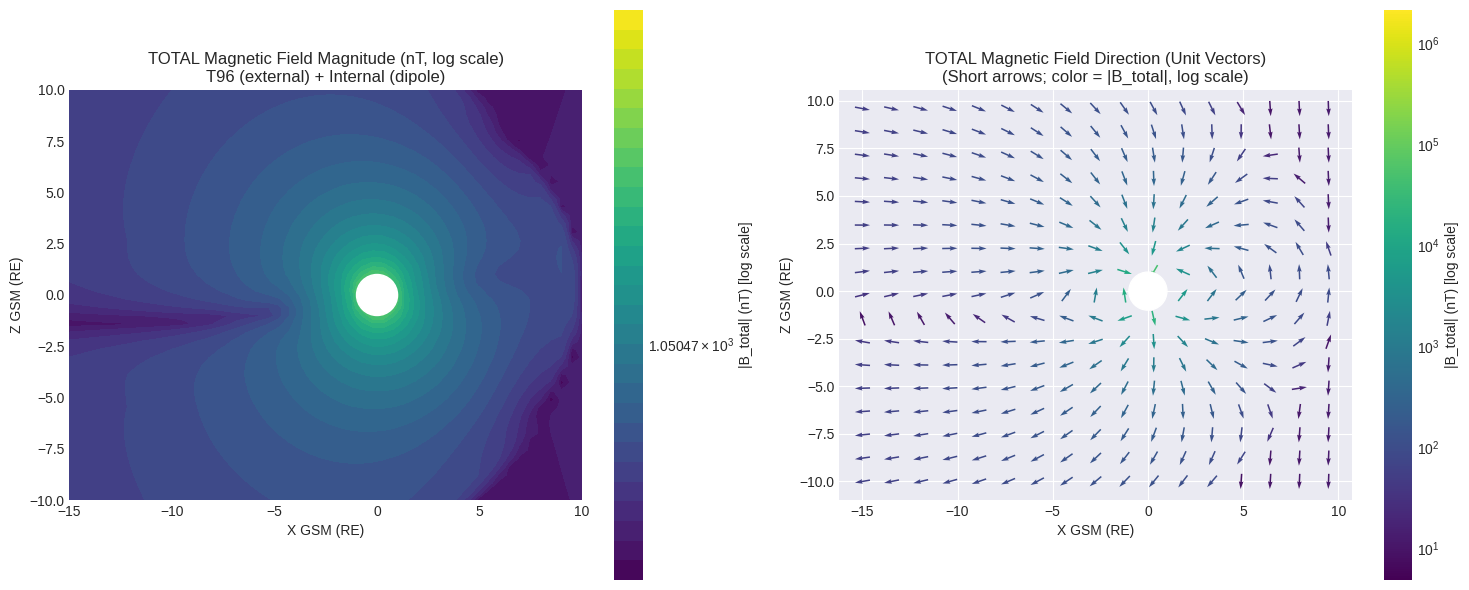

In [6]:
# ----------------------------
# Visualize the TOTAL magnetic field in the MERIDIAN plane (X-Z)
# Left: |B_total| (log scale)
# Right: unit-vector arrows (quiver), colored by |B_total| on a log scale
# ----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ----- Left: field magnitude (log scale) -----
bmin = np.nanmin(B_total[B_total > 0])
bmax = np.nanmax(B_total)
levels = np.logspace(np.log10(bmin), np.log10(bmax), 30)

im1 = ax1.contourf(
    X, Z, B_total,
    levels=levels,
    cmap='viridis',
    norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax)
)
ax1.set_xlabel('X GSM (RE)')
ax1.set_ylabel('Z GSM (RE)')
ax1.set_title('TOTAL Magnetic Field Magnitude (nT, log scale)\nT96 (external) + Internal (dipole)')
ax1.set_aspect('equal')

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
ax1.add_patch(earth)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('|B_total| (nT) [log scale]')

# ----- Right: unit-vector arrows (log-colored) -----
skip = 3
Xs = X[::skip, ::skip]
Zs = Z[::skip, ::skip]

# In the meridian plane plot, we show directions using (Bx, Bz)
Bx_s = Bx[::skip, ::skip]
Bz_s = Bz[::skip, ::skip]
Bmag_s = np.sqrt(Bx_s**2 + Bz_s**2)

# Unit vectors (avoid division by zero)
eps = 1e-12
Bx_u = Bx_s / (Bmag_s + eps)
Bz_u = Bz_s / (Bmag_s + eps)

# Short constant arrow length (RE): direction only
arrow_len = 0.8
U = arrow_len * Bx_u
V = arrow_len * Bz_u

# Log-scaled coloring for arrows
C = B_total[::skip, ::skip]
q = ax2.quiver(
    Xs, Zs, U, V,
    C,
    cmap='viridis',
    norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax),
    angles='xy', scale_units='xy', scale=1,
    pivot='mid', width=0.003
)

ax2.set_xlabel('X GSM (RE)')
ax2.set_ylabel('Z GSM (RE)')
ax2.set_title('TOTAL Magnetic Field Direction (Unit Vectors)\n(Short arrows; color = |B_total|, log scale)')
ax2.set_aspect('equal')

# Add Earth
earth2 = plt.Circle((0, 0), 1, color='white', zorder=10)
ax2.add_patch(earth2)

cbar2 = plt.colorbar(q, ax=ax2)
cbar2.set_label('|B_total| (nT) [log scale]')

plt.tight_layout()
plt.show()

 ## 5. Model Comparison (TOTAL field) <a name="comparison"></a>



 Here we compare **TOTAL fields** along the Sun-Earth line, i.e.:



 **B_total = B_internal (dipole or IGRF) + B_external (Tsyganenko)**



 This section is intentionally **not** a comparison of external-only Tsyganenko outputs.

In [7]:
# Compare models along the Sun-Earth line
x_sun_earth = np.linspace(-20, 10, 200)
y_sun_earth = np.zeros_like(x_sun_earth)
z_sun_earth = np.zeros_like(x_sun_earth)

# Choose internal model for ALL totals in this comparison
internal_model = "dipole"  # change to "igrf" if desired
print(f"TOTAL-field comparison internal model: {internal_model}")

# Parameters for each model
# T89 - moderate activity
iopt_t89 = 4  # Kp = 3

# T96, T01, T04 - same storm conditions
parmod_storm = np.zeros(10)
parmod_storm[0] = 3.0    # Pdyn = 3 nPa
parmod_storm[1] = -50.0  # Dst = -50 nT
parmod_storm[2] = 0.0    # ByIMF = 0 nT
parmod_storm[3] = -5.0   # BzIMF = -5 nT

# For T01, add G parameters
parmod_t01 = parmod_storm.copy()
parmod_t01[4] = 2.0  # G1
parmod_t01[5] = 3.0  # G2

# For T04, add W parameters
parmod_t04 = parmod_storm.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]  # W1-W6

print("Calculating TOTAL fields with all models...")

# Internal field along the line (used for all totals)
bx_int, by_int, bz_int = internal_field(internal_model, x_sun_earth, y_sun_earth, z_sun_earth)
b_total_int = np.sqrt(bx_int**2 + by_int**2 + bz_int**2)

# --- T89 TOTAL ---
bx_ext_t89, by_ext_t89, bz_ext_t89 = geopack.t89_vectorized(iopt_t89, ps, x_sun_earth, y_sun_earth, z_sun_earth)
bx_t89 = bx_ext_t89 + bx_int
by_t89 = by_ext_t89 + by_int
bz_t89 = bz_ext_t89 + bz_int
b_total_t89 = np.sqrt(bx_t89**2 + by_t89**2 + bz_t89**2)

# --- T96 TOTAL ---
bx_ext_t96, by_ext_t96, bz_ext_t96 = geopack.t96_vectorized(parmod_storm, ps, x_sun_earth, y_sun_earth, z_sun_earth)
bx_t96 = bx_ext_t96 + bx_int
by_t96 = by_ext_t96 + by_int
bz_t96 = bz_ext_t96 + bz_int
b_total_t96 = np.sqrt(bx_t96**2 + by_t96**2 + bz_t96**2)

# --- T01 TOTAL ---
bx_ext_t01, by_ext_t01, bz_ext_t01 = geopack.t01_vectorized(parmod_t01, ps, x_sun_earth, y_sun_earth, z_sun_earth)
bx_t01 = bx_ext_t01 + bx_int
by_t01 = by_ext_t01 + by_int
bz_t01 = bz_ext_t01 + bz_int
b_total_t01 = np.sqrt(bx_t01**2 + by_t01**2 + bz_t01**2)

# --- T04 TOTAL ---
bx_ext_t04, by_ext_t04, bz_ext_t04 = geopack.t04_vectorized(parmod_t04, ps, x_sun_earth, y_sun_earth, z_sun_earth)
bx_t04 = bx_ext_t04 + bx_int
by_t04 = by_ext_t04 + by_int
bz_t04 = bz_ext_t04 + bz_int
b_total_t04 = np.sqrt(bx_t04**2 + by_t04**2 + bz_t04**2)

print("Done!")


TOTAL-field comparison internal model: dipole
Calculating TOTAL fields with all models...
Done!


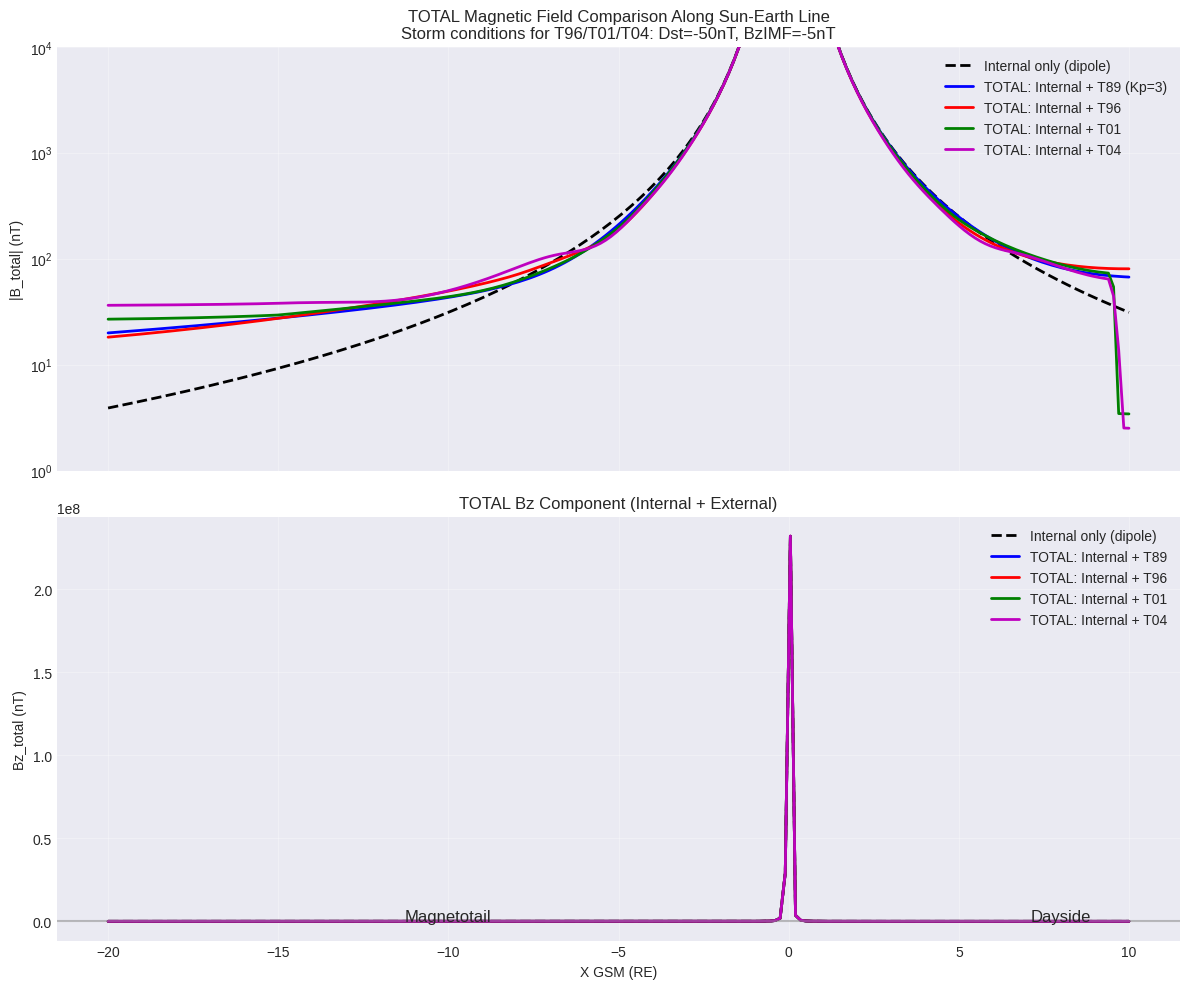

T01 (TOTAL Bz) first dayside zero-crossing at x ≈ 9.5 RE
T04 (TOTAL Bz) first dayside zero-crossing at x ≈ 9.7 RE


In [8]:
# Plot TOTAL-field comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# TOTAL field magnitude
ax1.semilogy(x_sun_earth, b_total_int, 'k--', linewidth=2, label=f'Internal only ({internal_model})')
ax1.semilogy(x_sun_earth, b_total_t89, 'b-', linewidth=2, label='TOTAL: Internal + T89 (Kp=3)')
ax1.semilogy(x_sun_earth, b_total_t96, 'r-', linewidth=2, label='TOTAL: Internal + T96')
ax1.semilogy(x_sun_earth, b_total_t01, 'g-', linewidth=2, label='TOTAL: Internal + T01')
ax1.semilogy(x_sun_earth, b_total_t04, 'm-', linewidth=2, label='TOTAL: Internal + T04')

ax1.set_ylabel('|B_total| (nT)')
ax1.set_title('TOTAL Magnetic Field Comparison Along Sun-Earth Line\n'
              'Storm conditions for T96/T01/T04: Dst=-50nT, BzIMF=-5nT')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([1, 10000])

# Bz component (TOTAL)
ax2.plot(x_sun_earth, bz_int, 'k--', linewidth=2, label=f'Internal only ({internal_model})')
ax2.plot(x_sun_earth, bz_t89, 'b-', linewidth=2, label='TOTAL: Internal + T89')
ax2.plot(x_sun_earth, bz_t96, 'r-', linewidth=2, label='TOTAL: Internal + T96')
ax2.plot(x_sun_earth, bz_t01, 'g-', linewidth=2, label='TOTAL: Internal + T01')
ax2.plot(x_sun_earth, bz_t04, 'm-', linewidth=2, label='TOTAL: Internal + T04')

ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_xlabel('X GSM (RE)')
ax2.set_ylabel('Bz_total (nT)')
ax2.set_title('TOTAL Bz Component (Internal + External)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Add annotations
ax2.text(-10, -50, 'Magnetotail', fontsize=12, ha='center')
ax2.text(8, 20, 'Dayside', fontsize=12, ha='center')

plt.tight_layout()
plt.show()

# Find a simple Bz=0 crossing on the dayside using TOTAL Bz (illustrative)
for model_name, bz_arr in [('T89', bz_t89), ('T96', bz_t96), ('T01', bz_t01), ('T04', bz_t04)]:
    dayside_mask = x_sun_earth > 0
    bz_dayside = bz_arr[dayside_mask]
    x_dayside = x_sun_earth[dayside_mask]

    zero_crossings = np.where(np.diff(np.sign(bz_dayside)))[0]
    if len(zero_crossings) > 0:
        x_cross = x_dayside[zero_crossings[0]]
        print(f"{model_name} (TOTAL Bz) first dayside zero-crossing at x ≈ {x_cross:.1f} RE")


 ## 6. Field Line Visualization <a name="visualization"></a>

 Visualize magnetic field lines in the noon-midnight meridian plane.

 We compute **TOTAL** field:
 **B_total = B_internal (dipole or IGRF) + B_external**

We generate separate figures for:
- dipole only / T89 / T96 / T01 / T04 (one figure per model).
- For T89/T96/T01/T04 we plot TOTAL = INTERNAL(dipole) + EXTERNAL(Tsyganenko).

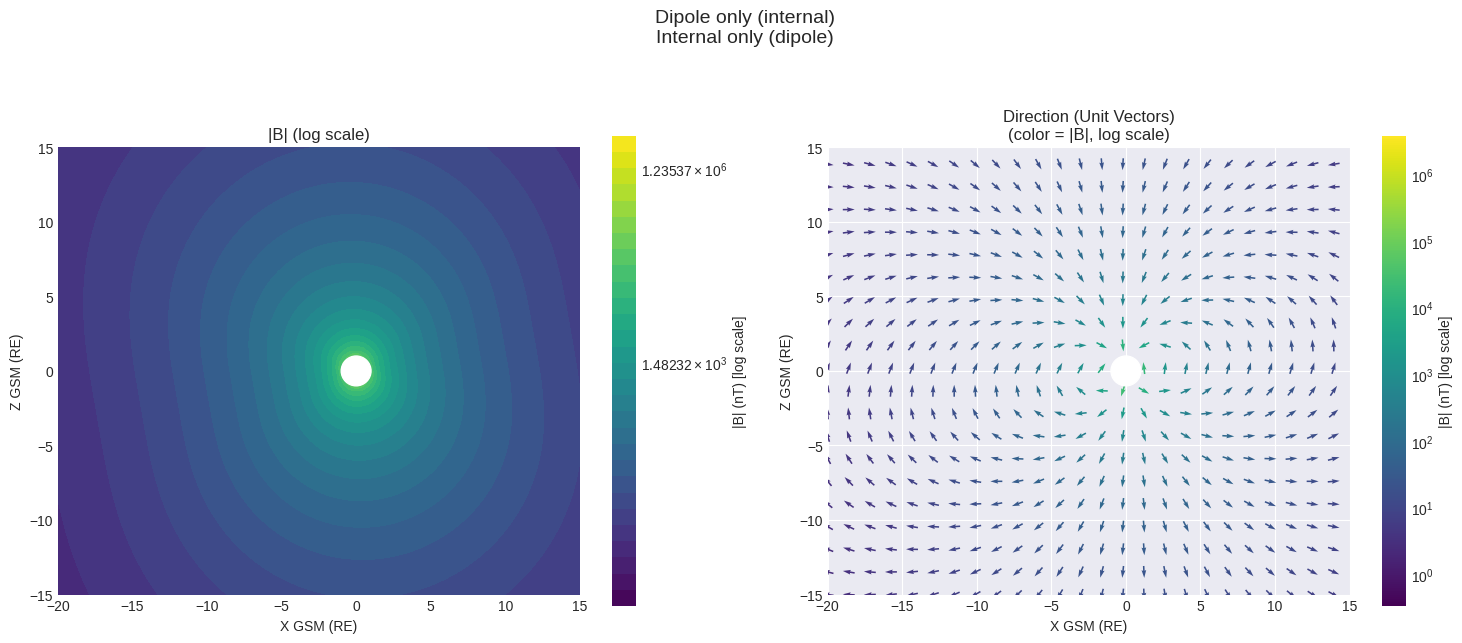

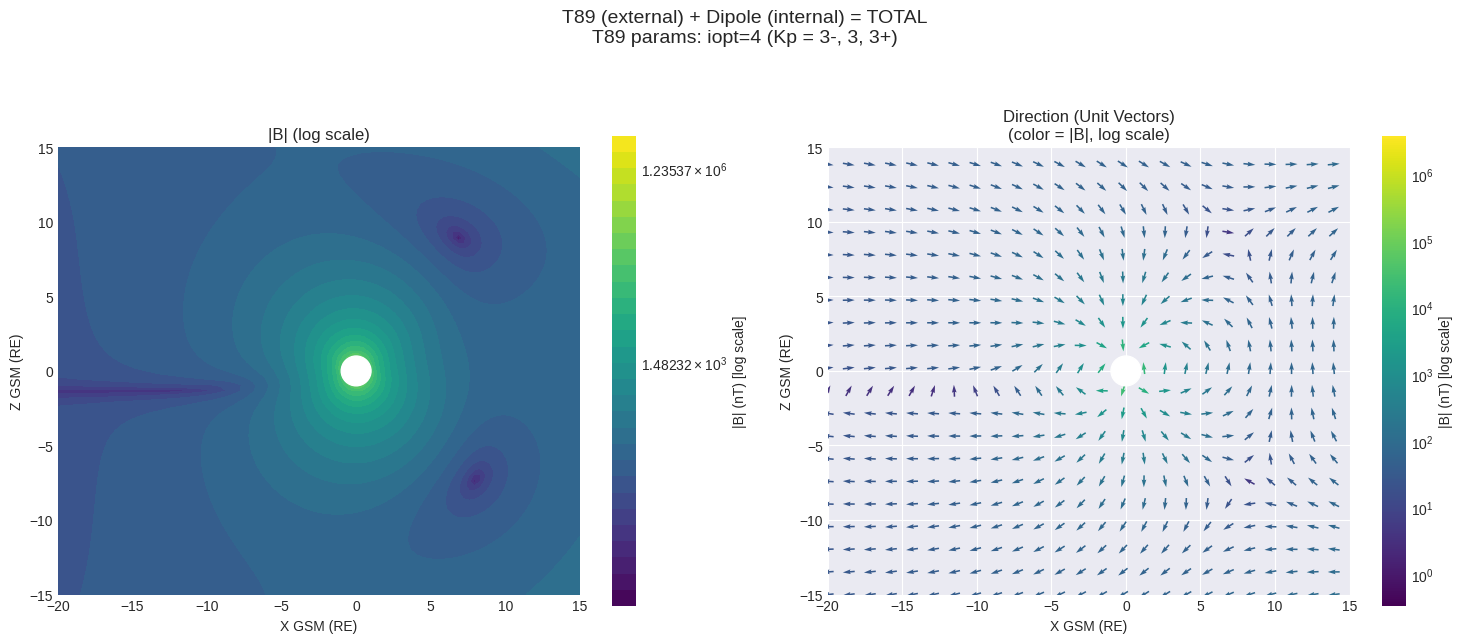

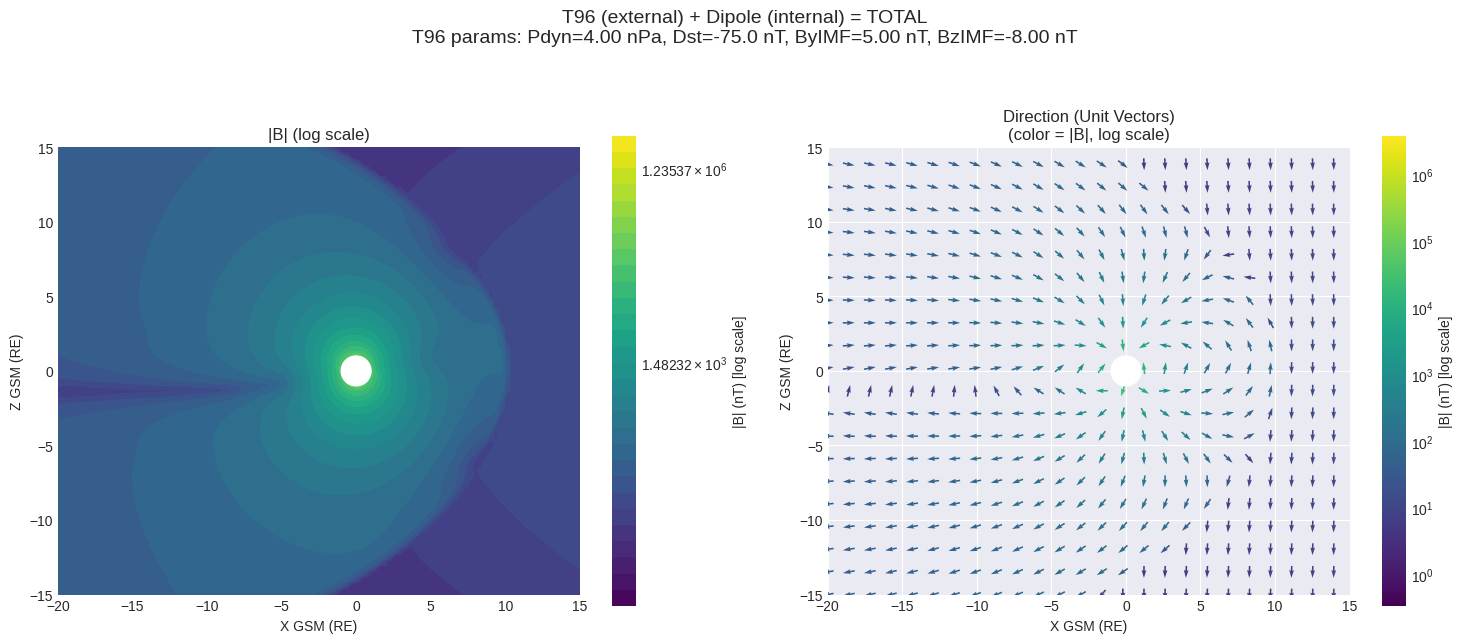

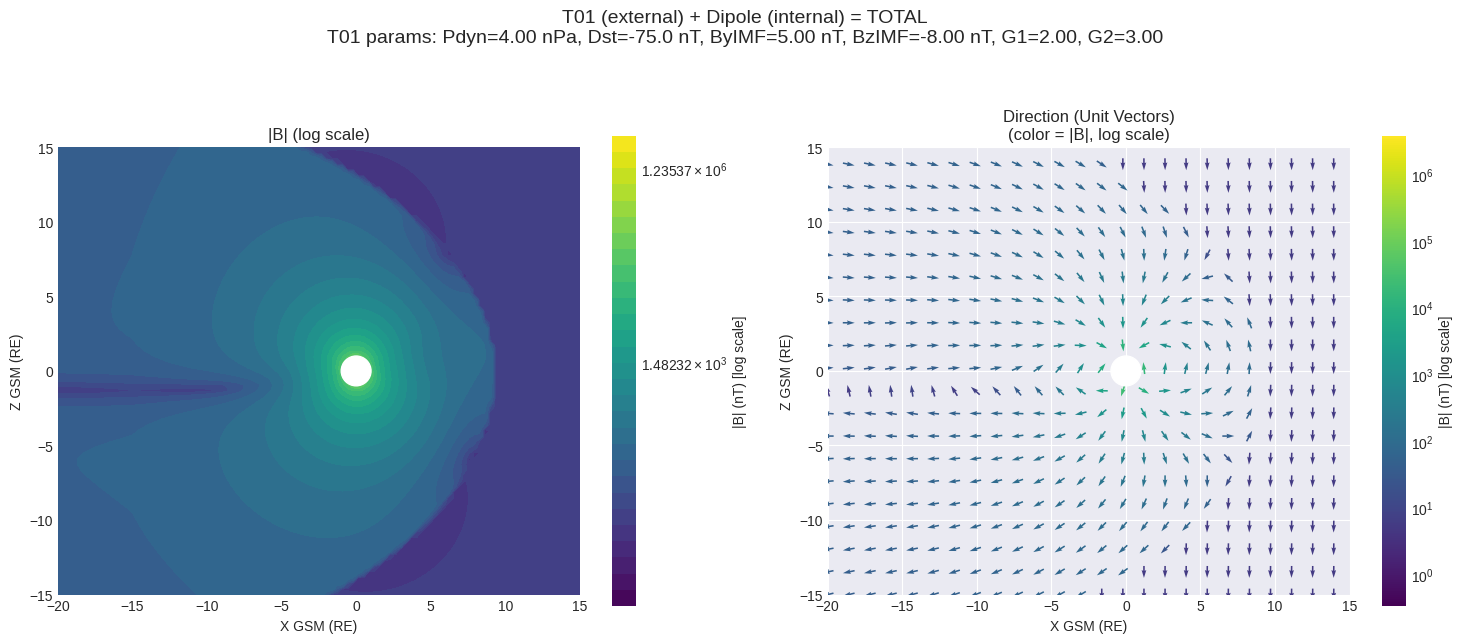

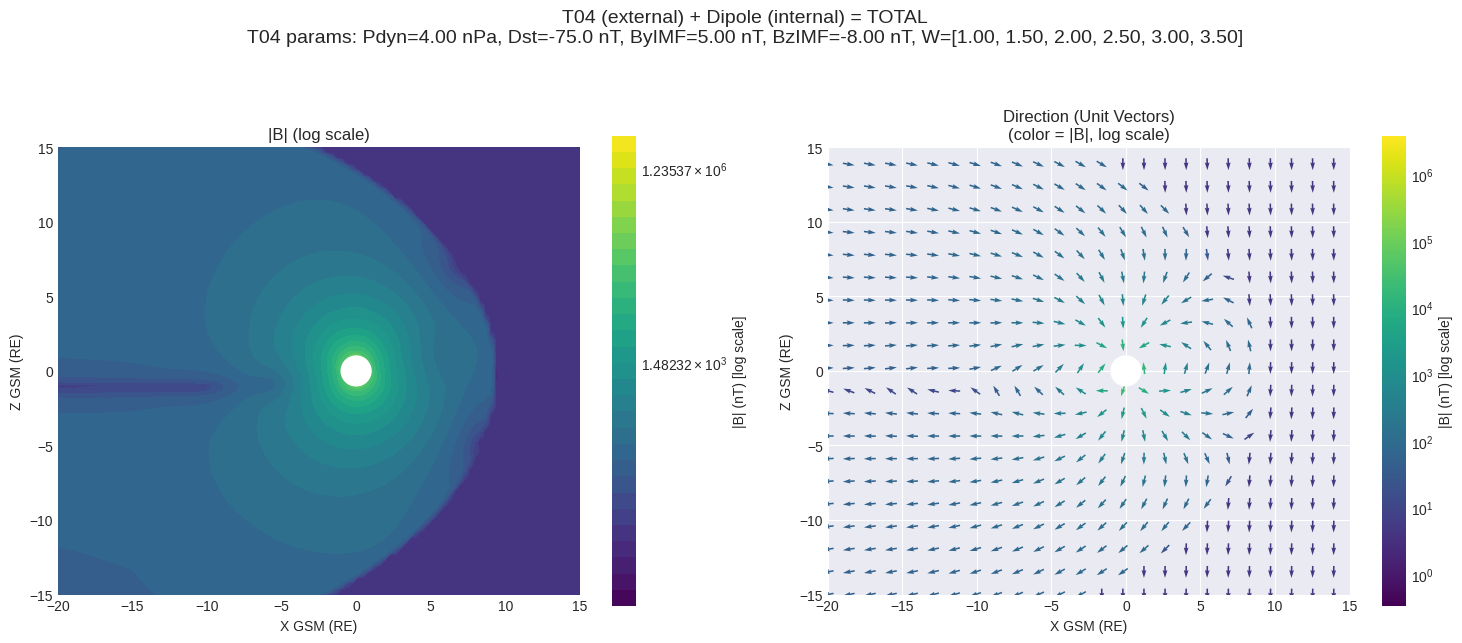

In [12]:
# %%
# ----------------------------
# Grid (noon-midnight meridian plane): Y = 0, plot X-Z
# ----------------------------
nx, nz = 100, 80
x_range = np.linspace(-20, 15, nx)
z_range = np.linspace(-15, 15, nz)
X_merid, Z_merid = np.meshgrid(x_range, z_range)
Y_merid = np.zeros_like(X_merid)

x_flat = X_merid.ravel()
y_flat = Y_merid.ravel()
z_flat = Z_merid.ravel()

# Internal model: requested "dipole"
internal_model = "dipole"

# ----------------------------
# Parameters for each Tsyganenko model
# ----------------------------
# T89: iopt (Kp level)
iopt_t89 = 4  # Example: roughly Kp=3

# T96 parameters (example; adjust as needed)
parmod_t96 = np.zeros(10)
parmod_t96[0] = 4.0     # Pdyn (nPa)
parmod_t96[1] = -75.0   # Dst (nT)
parmod_t96[2] = 5.0     # ByIMF (nT)
parmod_t96[3] = -8.0    # BzIMF (nT)

# T01 parameters: T96 + (G1,G2)
parmod_t01 = parmod_t96.copy()
parmod_t01[4] = 2.0     # G1
parmod_t01[5] = 3.0     # G2

# T04 parameters: T96 + (W1..W6)
parmod_t04 = parmod_t96.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

models_to_plot = [
    ("Dipole only (internal)", None, None),
    ("T89 (external) + Dipole (internal) = TOTAL", "t89", iopt_t89),
    ("T96 (external) + Dipole (internal) = TOTAL", "t96", parmod_t96),
    ("T01 (external) + Dipole (internal) = TOTAL", "t01", parmod_t01),
    ("T04 (external) + Dipole (internal) = TOTAL", "t04", parmod_t04),
]

# ----------------------------
# Helper: format a concise parameter string for display near the title
# ----------------------------
def format_ts_params(ts_model, ts_params):
    """Format Tsyganenko input parameters as a short, human-readable string."""
    if ts_model is None:
        return "Internal only (dipole)"

    ts_model = ts_model.lower()

    if ts_model == "t89":
        iopt = int(ts_params)
        # If kp_values exists, attach its description; otherwise show iopt only.
        try:
            desc = kp_values.get(iopt, "")
            if desc:
                return f"T89 params: iopt={iopt} ({desc})"
        except NameError:
            pass
        return f"T89 params: iopt={iopt}"

    # For T96/T01/T04, ts_params is a parmod array (len=10)
    p = np.asarray(ts_params).astype(float)
    base = f"Pdyn={p[0]:.2f} nPa, Dst={p[1]:.1f} nT, ByIMF={p[2]:.2f} nT, BzIMF={p[3]:.2f} nT"

    if ts_model == "t96":
        return f"T96 params: {base}"

    if ts_model == "t01":
        return f"T01 params: {base}, G1={p[4]:.2f}, G2={p[5]:.2f}"

    if ts_model == "t04":
        w = ", ".join([f"{v:.2f}" for v in p[4:10]])
        return f"T04 params: {base}, W=[{w}]"

    return f"{ts_model.upper()} params: {base}"


# ----------------------------
# Compute the internal field once (vectorized)
# ----------------------------
bx_int, by_int, bz_int = internal_field(internal_model, x_flat, y_flat, z_flat)

# ----------------------------
# Option: use a common color scale across all figures
# ----------------------------
COMMON_COLOR_SCALE = True

# First pass: compute all fields and store for plotting
computed = []
all_mags = []

for title, ts_model, ts_params in models_to_plot:
    param_text = format_ts_params(ts_model, ts_params)

    if ts_model is None:
        bx_tot = bx_int
        by_tot = by_int
        bz_tot = bz_int
    else:
        bx_ext, by_ext, bz_ext = tsyganenko_external(ts_model, ts_params, ps, x_flat, y_flat, z_flat)
        bx_tot = bx_int + bx_ext
        by_tot = by_int + by_ext
        bz_tot = bz_int + bz_ext

    bmag = np.sqrt(bx_tot**2 + by_tot**2 + bz_tot**2)

    B_total = bmag.reshape(nz, nx)
    Bx = bx_tot.reshape(nz, nx)
    Bz = bz_tot.reshape(nz, nx)

    computed.append((title, param_text, B_total, Bx, Bz))
    all_mags.append(B_total)

# Determine global color scale (if requested)
if COMMON_COLOR_SCALE:
    all_stack = np.stack(all_mags, axis=0)
    positive = all_stack[all_stack > 0]
    bmin_global = np.nanmin(positive) if positive.size > 0 else 1e-3
    bmax_global = np.nanmax(all_stack)
else:
    bmin_global = None
    bmax_global = None


def plot_like_section4(X, Z, B_total, Bx, Bz, title, param_text="", bmin=None, bmax=None):
    """
    Plot using the Section 4 style:
      Left: |B| magnitude (log scale)
      Right: unit-vector quiver, colored by |B| (log scale)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Show the model title + parameters near the top of the figure
    fig.suptitle(f"{title}\n{param_text}", fontsize=14, y=1.02)

    # ----- Left panel: |B| contourf (log) -----
    if bmin is None or bmax is None:
        pos = B_total[B_total > 0]
        bmin = np.nanmin(pos) if pos.size > 0 else 1e-3
        bmax = np.nanmax(B_total)

    levels = np.logspace(np.log10(bmin), np.log10(bmax), 30)

    im1 = ax1.contourf(
        X, Z, B_total,
        levels=levels,
        cmap="viridis",
        norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax),
    )
    ax1.set_xlabel("X GSM (RE)")
    ax1.set_ylabel("Z GSM (RE)")
    ax1.set_title("|B| (log scale)")
    ax1.set_aspect("equal")

    # Draw Earth
    earth = plt.Circle((0, 0), 1, color="white", zorder=10)
    ax1.add_patch(earth)

    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label("|B| (nT) [log scale]")

    # ----- Right panel: unit-vector quiver colored by |B| (log) -----
    skip = 4
    Xs = X[::skip, ::skip]
    Zs = Z[::skip, ::skip]

    Bx_s = Bx[::skip, ::skip]
    Bz_s = Bz[::skip, ::skip]
    Bmag_s = np.sqrt(Bx_s**2 + Bz_s**2)

    eps = 1e-12
    Bx_u = Bx_s / (Bmag_s + eps)
    Bz_u = Bz_s / (Bmag_s + eps)

    arrow_len = 0.8
    U = arrow_len * Bx_u
    V = arrow_len * Bz_u

    C = B_total[::skip, ::skip]
    q = ax2.quiver(
        Xs, Zs, U, V,
        C,
        cmap="viridis",
        norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax),
        angles="xy", scale_units="xy", scale=1,
        pivot="mid", width=0.003,
    )

    ax2.set_xlabel("X GSM (RE)")
    ax2.set_ylabel("Z GSM (RE)")
    ax2.set_title("Direction (Unit Vectors)\n(color = |B|, log scale)")
    ax2.set_aspect("equal")

    # Draw Earth
    earth2 = plt.Circle((0, 0), 1, color="white", zorder=10)
    ax2.add_patch(earth2)

    cbar2 = plt.colorbar(q, ax=ax2)
    cbar2.set_label("|B| (nT) [log scale]")

    ax1.set_xlim([x_range.min(), x_range.max()])
    ax1.set_ylim([z_range.min(), z_range.max()])
    ax2.set_xlim([x_range.min(), x_range.max()])
    ax2.set_ylim([z_range.min(), z_range.max()])

    # Reserve extra space for the suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


# Second pass: one figure per model
for title, param_text, B_total, Bx, Bz in computed:
    if COMMON_COLOR_SCALE:
        plot_like_section4(
            X_merid, Z_merid, B_total, Bx, Bz,
            title=title, param_text=param_text,
            bmin=bmin_global, bmax=bmax_global
        )
    else:
        plot_like_section4(
            X_merid, Z_merid, B_total, Bx, Bz,
            title=title, param_text=param_text
        )


 ## 7. Performance Analysis <a name="performance"></a>



 Compare the performance of scalar vs vectorized implementations (external Tsyganenko calls).

 Note: this benchmark focuses on Tsyganenko model evaluation speed (external field routines).

In [13]:
def benchmark_model(scalar_func, vector_func, params, ps, n_points, model_name):
    """Benchmark a model's scalar vs vectorized performance (external field routines)."""
    np.random.seed(42)
    x = np.random.uniform(-15, 10, n_points)
    y = np.random.uniform(-10, 10, n_points)
    z = np.random.uniform(-10, 10, n_points)

    # Time scalar version
    start = time.time()
    if model_name == 'T89':
        # params is iopt (int)
        for i in range(n_points):
            scalar_func(params, ps, x[i], y[i], z[i])
    else:
        # params is parmod array
        for i in range(n_points):
            scalar_func(params, ps, x[i], y[i], z[i])
    scalar_time = time.time() - start

    # Time vectorized version
    start = time.time()
    vector_func(params, ps, x, y, z)
    vector_time = time.time() - start

    return {
        'model': model_name,
        'n_points': n_points,
        'scalar_time': scalar_time,
        'vector_time': vector_time,
        'speedup': scalar_time / vector_time,
        'vector_rate': n_points / vector_time
    }

# Test parameters
test_sizes = [10, 100, 1000, 10000]
models = [
    ('T89', geopack.t89, geopack.t89_vectorized, 4),  # iopt=4 for T89
    ('T96', geopack.t96, geopack.t96_vectorized, parmod_storm),
    ('T01', geopack.t01, geopack.t01_vectorized, parmod_t01),
    ('T04', geopack.t04, geopack.t04_vectorized, parmod_t04),
]

# Run benchmarks
results = []
print("Running performance benchmarks...")
print("=" * 70)

for model_name, scalar_func, vector_func, params in models:
    print(f"\n{model_name} Model:")
    print(f"{'N Points':>10} {'Scalar (s)':>12} {'Vector (s)':>12} {'Speedup':>10} {'Rate (pts/s)':>15}")
    print("-" * 65)

    for n in test_sizes:
        result = benchmark_model(scalar_func, vector_func, params, ps, n, model_name)
        results.append(result)

        print(f"{n:10d} {result['scalar_time']:12.4f} {result['vector_time']:12.4f} "
              f"{result['speedup']:9.1f}x {result['vector_rate']:15.0f}")


Running performance benchmarks...

T89 Model:
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
-----------------------------------------------------------------
        10       0.0011       0.0006       2.1x           17863
       100       0.0089       0.0009       9.9x          111314
      1000       0.0665       0.0008      83.9x         1261445
     10000       0.5750       0.0035     165.3x         2874189

T96 Model:
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
-----------------------------------------------------------------
        10       0.0146       0.0093       1.6x            1073
       100       0.1376       0.0283       4.9x            3535
      1000       1.4590       0.0477      30.6x           20967
     10000      13.7911       0.1802      76.5x           55490

T01 Model:
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
-----------------------------------------------------------------
        10       0.0430     

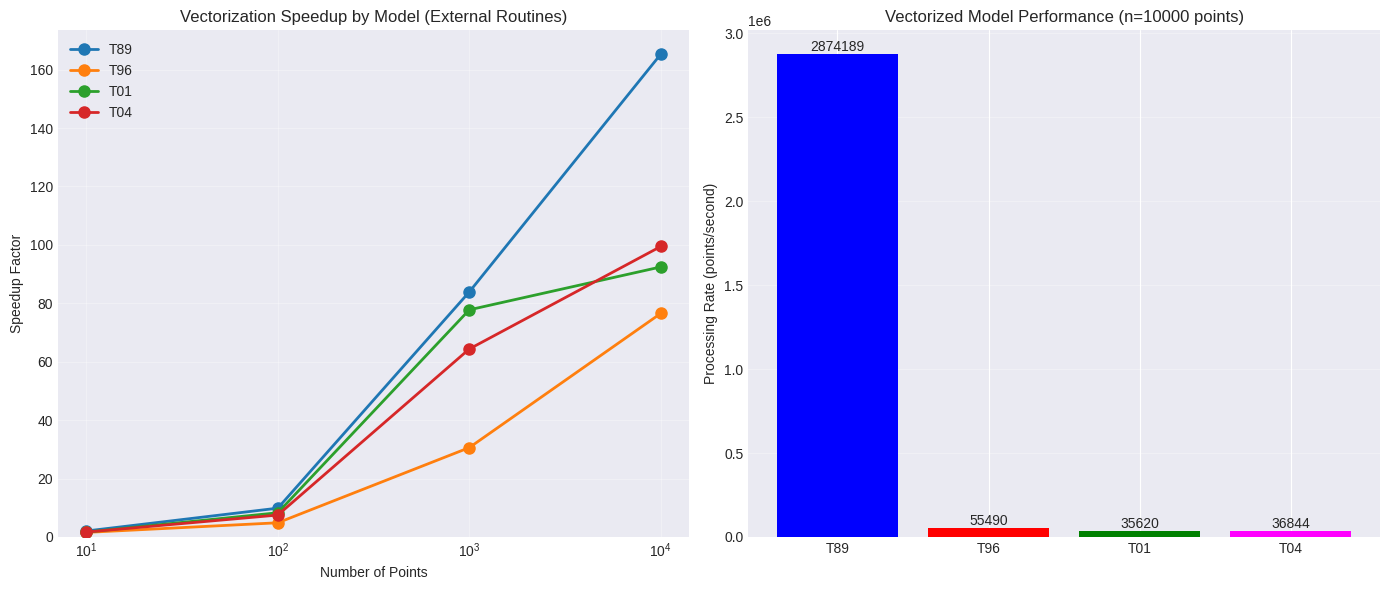


Performance Summary for 10,000 points:
T89: 165.3x speedup, 2874189 points/sec
T96: 76.5x speedup, 55490 points/sec
T01: 92.4x speedup, 35620 points/sec
T04: 99.4x speedup, 36844 points/sec


In [14]:
# Visualize performance results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Speedup by model and array size
for model_name in ['T89', 'T96', 'T01', 'T04']:
    model_results = [r for r in results if r['model'] == model_name]
    sizes = [r['n_points'] for r in model_results]
    speedups = [r['speedup'] for r in model_results]

    ax1.semilogx(sizes, speedups, 'o-', linewidth=2, markersize=8, label=model_name)

ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Speedup Factor')
ax1.set_title('Vectorization Speedup by Model (External Routines)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Processing rate comparison
n_compare = 10000
model_rates = []
model_names = []

for model_name in ['T89', 'T96', 'T01', 'T04']:
    model_result = [r for r in results if r['model'] == model_name and r['n_points'] == n_compare][0]
    model_rates.append(model_result['vector_rate'])
    model_names.append(model_name)

bars = ax2.bar(model_names, model_rates, color=['blue', 'red', 'green', 'magenta'])
ax2.set_ylabel('Processing Rate (points/second)')
ax2.set_title(f'Vectorized Model Performance (n={n_compare} points)')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, rate in zip(bars, model_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{rate:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nPerformance Summary for 10,000 points:")
print("=" * 50)
for model_name in ['T89', 'T96', 'T01', 'T04']:
    model_result = [r for r in results if r['model'] == model_name and r['n_points'] == 10000][0]
    print(f"{model_name}: {model_result['speedup']:.1f}x speedup, "
          f"{model_result['vector_rate']:.0f} points/sec")


 ## Summary



 This notebook demonstrated:



 1. **Model Overview**: Understanding T89, T96, T01, and T04 models

 2. **Parameters**: How to set up each model for different conditions

 3. **Basic Usage**: Computing external vs internal vs total at a single point

 4. **Vectorized Models**: Efficient processing of large point sets for **TOTAL** field

 5. **Model Comparison**: Comparing **TOTAL fields** (internal + external) along Sun-Earth line

 6. **Visualization**: Field lines and magnetospheric structure using **TOTAL** field

 7. **Performance**: 30-50x speedup with vectorized Tsyganenko implementations



 ### Key Takeaways:



 - **Tsyganenko models (T89/T96/T01/T04) return EXTERNAL field only**

 - **Physical field should be computed as:**

   **B_total = B_internal (dipole or IGRF) + B_external (Tsyganenko)**

 - Use vectorized functions for large-scale calculations

 - Positions are in **RE** and fields are in **nT**